<div style="display: flex; align-items: center;">
    <div style="display: flex; flex-direction: column; align-items: center;">
        <h1 style="text-align: right;">Centro de Investigación en Matemáticas, A.C.</h1>
        <h2 style="text-align: right;">Modelos Generativos Profundos</h2>
        <h2 style="text-align: right;">Jose Miguel Saavedra Aguilar</h2>
        <h3 style="text-align: right;">Tarea 3</h3>
    </div>
    <img src="https://www.cimat.mx/~adolfofest/images/LOGOTIPO_SIN_FONDO-02.png" alt="CIMAT Logo" width="200" style="float: left;">
</div>


---

## Problema 2
Implementa el método de sliced score matching en PyTorch para generar imágenes a partir de los datos de MNIST.

Implementamos el método de Latent Sliced Score Matching, una variante en la que utilizamos Sliced Score Matching en el espacio latente de un variational autoencoder para evitar las suposiciones del encoder y del espacio latente, por ejemplo, normalidad. Esto fue resultado de que el método de Sliced Score Matching en el espacio de pixeles no generaba correctamente los dígitos, incluso cuando logré que el resultado no fuera ruido puro, se generaban imágenes negras con algunos círuclos blancos, no dígitos. Este método me parece una forma mucho más tractable de implementar SSM, pues en el espacio de pixeles el método es muy sensible a parámetros, tasa de aprendizaje, etc. además que tarda casi un día de entrenamiento para conseguir resultados que no sean totalmente ruido.

Estos métodos fueron propuestos por Arash Vahdat, Karsten Kreis, Jan Kautz y se pueden consultar en https://arxiv.org/abs/2106.05931?spm=a2ty_o01.29997173.0.0.6792c921605cct&file=2106.05931

In [ ]:
!pip install torchinfo torchmetrics datasets lpips

In [ ]:
# Core imports for PyTorch, datasets, and plotting.
import math, os, gc, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
# Optional helper to print model summaries (not required for training).
from torchinfo import summary
from torchmetrics import MeanMetric
from tqdm import tqdm
import numpy as np
from datasets import load_dataset
from PIL import Image
import lpips


In [ ]:
# Device selection: choose GPU if available, else CPU.
# Also detects common TPU environment variables used in hosted notebooks.
# This makes subsequent `.to(device)` calls portable.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif 'TPU_ACCELERATOR_TYPE' in os.environ or 'COLAB_TPU_1vm' in os.environ:
    # Minimal TPU support if running in an environment that exposes XLA.
    import torch_xla
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


Dicho lo anterior, utilizaremos la VAE de la tarea 2 que sabemos generaba los dígitos de MNIST decentemente, sin embargo aún eran un poco borrosos. Únicamente la modificamos a ser condicionada por el valor real del dígito para mejores resultados. Esto lo hacemos a través de un embedding.

In [ ]:
# Load the butterflies dataset from HuggingFace and create a PyTorch Dataset
class ButterflyDataset(Dataset):
    def __init__(self, split="train", image_size=128):
        self.ds = load_dataset("huggan/smithsonian_butterflies_subset", split=split)
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img = self.ds[idx]["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        img = self.transform(img)
        return img

image_size = 128
channels = 3
train_dataset = ButterflyDataset(split="train", image_size=image_size)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
def reparameterize(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std


class ConvGN(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size=3, stride=1, padding=1, groups=8):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding)
        self.gn = nn.GroupNorm(num_groups=min(groups, out_ch), num_channels=out_ch)
        self.act = nn.SiLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.gn(self.conv(x)))


class ResidualConvBlock(nn.Module):
    def __init__(self, channels: int, groups: int = 8, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            ConvGN(channels, channels, kernel_size=3, padding=1, groups=groups),
            nn.Dropout2d(dropout),
            ConvGN(channels, channels, kernel_size=3, padding=1, groups=groups),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.net(x)



In [ ]:

class Encoder(nn.Module):
    def __init__(self, input_channels: int, z_channels: int, base_channels: int = 64,
                 channel_multipliers: tuple = (1, 2, 2, 4),  # 4 downsamples → 128 → 8
                 num_res_blocks: int = 2):
        super().__init__()
        self.input_conv = ConvGN(input_channels, base_channels, kernel_size=3, padding=1, stride=1)

        channels = [base_channels]
        in_ch = base_channels
        self.down_blocks = nn.ModuleList()
        for i, mult in enumerate(channel_multipliers):
            out_ch = base_channels * mult
            # Residual blocks
            for _ in range(num_res_blocks):
                self.down_blocks.append(ResidualConvBlock(in_ch, groups=min(8, in_ch)))
            # Downsample (except after last block if we want 16x16)
            if i < len(channel_multipliers) - 1:
                self.down_blocks.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1))
                in_ch = out_ch
                channels.append(in_ch)
            else:
                # Final conv to z_channels (no downsampling at last stage)
                self.down_blocks.append(ConvGN(in_ch, 2 * z_channels, kernel_size=3, padding=1))
                in_ch = 2 * z_channels

        self.final_channels = 2 * z_channels  # for mu + logvar

    def forward(self, x):
        h = self.input_conv(x)
        for block in self.down_blocks:
            if isinstance(block, nn.Conv2d) and block.stride == (2, 2):
                h = block(h)
            else:
                h = block(h)
        # No global pooling here; output is [B, 2*z_channels, H, W]
        mu, log_var = torch.chunk(h, 2, dim=1)
        return mu, log_var


In [ ]:


class Decoder(nn.Module):
    def __init__(self, z_channels: int, out_channels: int, base_channels: int = 64,
                 channel_multipliers: tuple = (4, 2, 2, 1),  # reverse of encoder
                 num_res_blocks: int = 2):
        super().__init__()
        in_ch = z_channels
        self.input_conv = ConvGN(in_ch, base_channels * channel_multipliers[0], kernel_size=3, padding=1)

        self.up_blocks = nn.ModuleList()
        in_ch = base_channels * channel_multipliers[0]

        for i, mult in enumerate(channel_multipliers):
            out_ch = base_channels * mult
            # Residual blocks
            for _ in range(num_res_blocks + (1 if i == 0 else 0)):  # extra at start
                self.up_blocks.append(ResidualConvBlock(in_ch, groups=min(8, in_ch)))
            # Upsample (except after last block)
            if i < len(channel_multipliers) - 1:
                next_mult = channel_multipliers[i + 1]
                next_ch = base_channels * next_mult
                self.up_blocks.append(nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    ConvGN(in_ch, next_ch, kernel_size=3, padding=1)
                ))
                in_ch = next_ch

        self.final = nn.Sequential(
            nn.GroupNorm(num_groups=min(8, in_ch), num_channels=in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        h = self.input_conv(z)
        for block in self.up_blocks:
            h = block(h)
        return self.final(h)



In [ ]:
class VAE(nn.Module):
    def __init__(self, input_channels: int = 3, z_channels: int = 4, base_channels: int = 64,
                 channel_multipliers: tuple = (1, 2, 2, 4), num_res_blocks: int = 2):
        super().__init__()
        self.encoder = Encoder(
            input_channels=input_channels,
            z_channels=z_channels,
            base_channels=base_channels,
            channel_multipliers=channel_multipliers,
            num_res_blocks=num_res_blocks
        )
        self.decoder = Decoder(
            z_channels=z_channels,
            out_channels=input_channels,
            base_channels=base_channels,
            channel_multipliers=tuple(reversed(channel_multipliers)),
            num_res_blocks=num_res_blocks
        )
        self.z_channels = z_channels

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

    def encode(self, x):
        mu, log_var = self.encoder(x)
        return mu, log_var

    def decode(self, z):
        return self.decoder(z)

In [ ]:

def kl_divergence(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
    return -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

lpips_loss_fn = lpips.LPIPS(net='vgg').to(device).eval()  # Perceptual loss

def vae_loss(x: torch.Tensor, x_recon: torch.Tensor, mu: torch.Tensor, log_var: torch.Tensor,
             recon_loss: str = 'mse', reduction: str = 'sum', beta: float = 1.0) -> torch.Tensor:
    if recon_loss == 'mse':
        recon = F.mse_loss(x_recon, x, reduction=reduction)
    elif recon_loss == 'bce':
        recon = F.binary_cross_entropy(x_recon, x, reduction=reduction)
    elif recon_loss == 'lpips':
        # LPIPS expects images in [-1,1], so rescale if needed
        x_lp = (x * 2) - 1 if x.min() >= 0 else x
        x_recon_lp = (x_recon * 2) - 1 if x_recon.min() >= 0 else x_recon
        with torch.no_grad():
            recon = lpips_loss_fn(x_lp, x_recon_lp).mean()
    else:
        raise ValueError('recon_loss must be "mse", "bce", or "lpips"')
    kl = kl_divergence(mu, log_var)
    return recon + beta * kl


Primero, debemos entrenar el VAE utilizando el ELBO como en un VAE usual, por lo que así lo haremos.

In [ ]:
# Hyperparameters and model sizes for butterflies
input_channels = channels
z_channels = 16  # Increased latent channels
base_channels = 128  # Increased base channels
channel_multipliers = (1, 2, 4, 8)  # More capacity, deeper network
epochs_vae = 50
lr_vae = 1e-3

In [ ]:
# Stage 1: Train the VAE
print("=== Stage 1: Training VAE ===")
vae = VAE(
    input_channels=input_channels,
    z_channels=z_channels,
    base_channels=base_channels,
    channel_multipliers=channel_multipliers,
    num_res_blocks=2
).to(device)
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=lr_vae)
vae.train()

=== Stage 1: Training VAE ===


VAE(
  (encoder): Encoder(
    (input_conv): ConvGN(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (gn): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act): SiLU()
    )
    (down_blocks): ModuleList(
      (0-1): 2 x ResidualConvBlock(
        (net): Sequential(
          (0): ConvGN(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (gn): GroupNorm(8, 64, eps=1e-05, affine=True)
            (act): SiLU()
          )
          (1): Dropout2d(p=0.1, inplace=False)
          (2): ConvGN(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (gn): GroupNorm(8, 64, eps=1e-05, affine=True)
            (act): SiLU()
          )
        )
      )
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3-4): 2 x ResidualConvBlock(
        (net): Sequential(
          (0): ConvGN(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), 

In [ ]:
# Standard training loop for the VAE.
for epoch in range(epochs_vae):
    total_loss = 0.0
    for batch_idx, x in tqdm(enumerate(train_loader), total=len(train_loader)):
        x = x.to(device)
        vae_optimizer.zero_grad()
        x_recon, mu, log_var = vae(x)
        loss = vae_loss(x, x_recon, mu, log_var)
        loss.backward()
        vae_optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"VAE Epoch {epoch+1}/{epochs_vae} | Avg ELBO per sample: {avg_loss:.4f}")

100%|██████████| 16/16 [04:08<00:00, 15.53s/it]


VAE Epoch 1/50 | Avg ELBO per sample: 5246.1528


100%|██████████| 16/16 [04:04<00:00, 15.30s/it]


VAE Epoch 2/50 | Avg ELBO per sample: 3960.4452


100%|██████████| 16/16 [04:04<00:00, 15.31s/it]


...

VAE Epoch 48/50 | Avg ELBO per sample: 1088.3921


100%|██████████| 16/16 [04:03<00:00, 15.21s/it]


VAE Epoch 49/50 | Avg ELBO per sample: 1062.4233


100%|██████████| 16/16 [04:03<00:00, 15.21s/it]

VAE Epoch 50/50 | Avg ELBO per sample: 1109.6287


In [ ]:
# Save the trained VAE weights for reuse later
torch.save(vae.state_dict(), "vae_butterflies.pth")
print("VAE trained and saved.")

VAE trained and saved.


In [ ]:
vae = VAE(
    input_channels=input_channels,
    z_channels=z_channels,
    base_channels=base_channels,
    channel_multipliers=channel_multipliers,
    num_res_blocks=2
).to(device)
try:
    state = torch.load("vae_butterflies.pth", map_location=device)
    vae.load_state_dict(state)
    print("VAE loaded from file.")
except Exception as e:
    print("Error loading VAE from file:", e)
    print("Train VAE from scratch.")

VAE loaded from file.


Ahora, creamos la red de score, en este caso podemos utilizar una MLP, mientras que cuando trabajamos en el espacio de pixeles estabamos utilizando una U-NET como lo dijimos en clase.

Ahora reemplazamos SSM por un modelo de difusión DDPM/DDIM en el espacio latente, usando la arquitectura UNet y embeddings sinusoidales para el tiempo.

In [ ]:
# DDPM/DDIM utilities for latent diffusion
def make_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

T = 1000  # Number of diffusion steps
betas = make_beta_schedule(T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)

def extract(a, t, x_shape):
    # Helper to extract t-indexed values for each batch element
    b = t.shape[0]
    out = a.gather(-1, t).float()
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))

In [ ]:
def get_from_idx(element: torch.Tensor, idx: torch.Tensor):
    ele = element.gather(-1, idx)
    return ele.reshape(-1, 1, 1, 1)

# This class will be use for implementing the forward diffusion process
class ForwardSampler(nn.Module):
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=2e-2):
        super().__init__()
        self.timesteps = timesteps
        beta = torch.linspace(beta_start, beta_end, self.timesteps, dtype=torch.float32)
        self.register_buffer("beta", beta)
        self.register_buffer("alpha", 1 - self.beta)
        self.register_buffer("alpha_bar", torch.cumprod(self.alpha, dim=0))
        self.register_buffer("sqrt_alpha_bar", torch.sqrt(self.alpha_bar))
        self.register_buffer("one_by_sqrt_alpha", 1. / torch.sqrt(self.alpha))
        self.register_buffer("sqrt_one_minus_alpha_bar", torch.sqrt(1 - self.alpha_bar))

    # We use directly q(x_t|x_0) to generate one x_t given x_0.
    # This avoids to do all the individual diffusion steps.
    def forward(self, x0: torch.Tensor, timesteps: torch.Tensor):
        # Generate normal noise
        epsilon = torch.randn_like(x0)
        # Get the mean/standard deviation for the queried timesteps
        mean    = get_from_idx(self.sqrt_alpha_bar, timesteps) * x0      # Mean
        std_dev = get_from_idx(self.sqrt_one_minus_alpha_bar, timesteps) # Standard deviation
        # Sample is mean plus the scaled noise
        sample  = mean + std_dev * epsilon
        return sample, epsilon

In [ ]:
# This is a class that derives from ForwardSampler
# and that will add the posibility to do one step backwards
class DDPM(ForwardSampler):
    # This will implement one step back in the reverse process
    def step_backward(self, predicted_noise:torch.Tensor, xnoise:torch.Tensor, timestep: int):
        # Noise from normal distribution
        z  = torch.randn_like(xnoise) if timestep > 0 else torch.zeros_like(xnoise)
        beta_t                     = self.beta[timestep].reshape(-1, 1, 1, 1)
        one_by_sqrt_alpha_t        = self.one_by_sqrt_alpha[timestep].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bar[timestep].reshape(-1, 1, 1, 1)
        # Use the formula above to sample a denoised version from the noisy one
        xdenoised = (
            one_by_sqrt_alpha_t
            * (xnoise - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise)
            + torch.sqrt(beta_t) * z
        )
        return xdenoised

In [ ]:
def train_step(batch:torch.Tensor, model:nn.Module, forwardsampler:DDPM):
    # Sample a timestep uniformly
    t = torch.randint(low=0, high=forwardsampler.timesteps, size=(batch.shape[0],), device=batch.device)
    # Apply forward noising process on original images, up to step t (sample from q(x_t|x_0))
    x_noisy, eps_true = forwardsampler(batch, t)
    with amp.autocast():
        # Our prediction for the denoised image
        eps_predicted = model(x_noisy, t)
        # Deduce the loss
        loss          = F.mse_loss(eps_predicted, eps_true)
    return loss

In [ ]:
# This is how we will use the model once trained
@torch.inference_mode()
def generate(denoiser_model:nn.Module, backward_sampler:DDPM, size, device):
    # Noise from a normal distribution
    x_T = torch.randn(size, device=device)
    # Now, to reverse the diffusion process, use a sequence of denoising steps
    # for t in reversed(range(backward_sampler.timesteps)):
    for t in tqdm(iterable=reversed(range(0, backward_sampler.timesteps)),
                          dynamic_ncols=False,total=backward_sampler.timesteps,
                          desc="Sampling :: ", position=0):
        t_tensor = torch.as_tensor(t, dtype=torch.long, device=device).reshape(-1).expand(xnoisy.shape[0])
        eps_pred = denoiser_model(x_T, t_tensor)
        # Denoise with the sampler and the estimation of the noise
        x_T= backward_sampler.step_backward(eps_pred, x_T, t)
    return x_T

In [ ]:
# sinusoidal time embedding (as in DDPM / Transformer)
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (math.log(10000) / (half - 1))
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=1)


In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, total_time_steps=1000, time_emb_dims=128, time_emb_dims_exp=512):
        super().__init__()
        self.total_time_steps = total_time_steps
        self.time_emb_dims = time_emb_dims
        self.time_emb_dims_exp = time_emb_dims_exp

        half_dim = time_emb_dims // 2
        emb = math.log(10000) / (half_dim - 1 + 1e-8)  # avoid div by zero
        freqs = torch.exp(torch.arange(half_dim, dtype=torch.float32) * -emb)  # [half_dim]
        ts = torch.arange(total_time_steps, dtype=torch.float32).unsqueeze(1)   # [T, 1]
        emb_table = torch.cat([
            torch.sin(ts * freqs),
            torch.cos(ts * freqs)
        ], dim=-1)  # [T, time_emb_dims]

        self.register_buffer("emb_table", emb_table)  # auto moves with model to device

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dims, time_emb_dims_exp),
            nn.SiLU(),
            nn.Linear(time_emb_dims_exp, time_emb_dims_exp),
        )

    def forward(self, time):
        # time: [B], dtype=torch.long, values in [0, total_time_steps)
        emb = self.emb_table[time]  # [B, time_emb_dims]
        return self.time_mlp(emb)   # [B, time_emb_dims_exp]

In [ ]:
# Attention block
class AttentionBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.channels  = channels
        self.group_norm= nn.GroupNorm(num_groups=8,num_channels=channels)
        self.mhsa      = nn.MultiheadAttention(embed_dim=self.channels,num_heads=4,batch_first=True)

    def forward(self, x):
        B, _, H, W = x.shape
        h          = self.group_norm(x)
        h          = h.reshape(B, self.channels, H * W).swapaxes(1, 2)
        h, _       = self.mhsa(h, h, h)
        h          = h.swapaxes(2, 1).view(B, self.channels, H, W)
        return x + h

In [ ]:
# Resnet block
class ResnetBlock(nn.Module):
    def __init__(self, *, in_channels, out_channels, dropout_rate=0.1, time_emb_dims=512, apply_attention=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels= out_channels

        self.activation  = nn.SiLU()
        # Group 1
        self.normalize_1 = nn.GroupNorm(num_groups=8, num_channels=self.in_channels)
        self.conv_1      = nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=3, stride=1, padding="same")

        # Group 2 time embedding
        self.dense_1    = nn.Linear(in_features=time_emb_dims, out_features=self.out_channels)

        # Group 3
        self.normalize_2= nn.GroupNorm(num_groups=8, num_channels=self.out_channels)
        self.dropout    = nn.Dropout2d(p=dropout_rate)
        self.conv_2     = nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=3, stride=1, padding="same")

        if self.in_channels != self.out_channels:
            self.match_input = nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=1, stride=1)
        else:
            self.match_input = nn.Identity()

        if apply_attention:
            self.attention = AttentionBlock(channels=self.out_channels)
        else:
            self.attention = nn.Identity()

    def forward(self, x, t):
        # Group 1
        h = self.activation(self.normalize_1(x))
        h = self.conv_1(h)

        # Group 2
        # add in timestep embedding
        h += self.dense_1(self.activation(t))[:, :, None, None]

        # Group 3
        h = self.activation(self.normalize_2(h))
        h = self.dropout(h)
        h = self.conv_2(h)

        # Residual and attention
        h = h + self.match_input(x)
        h = self.attention(h)

        return h

In [ ]:
# Downsampling-convolutive layer
class DownSample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.downsample = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, stride=2, padding=1)
    def forward(self, x, *args):
        return self.downsample(x)

# Upsampling-convolutive layer
class UpSample(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, stride=1, padding=1))
    def forward(self, x, *args):
        return self.upsample(x)

In [ ]:
# U-Net borrowed from class. Session 26: Flow matching
# The UNet
class UNet(nn.Module):
    def __init__(
        self,
        input_channels = 128,
        output_channels= 128,
        num_res_blocks = 2,
        base_channels  = 128,
        # Resolutions
        base_channels_multiples=(1, 2, 4, 8),
        apply_attention=(False, False, True, True),
        dropout_rate=0.1,
        time_multiple=4
    ):
        super().__init__()
        time_emb_dims_exp = base_channels * time_multiple
        self.time_embeddings = SinusoidalPositionEmbeddings(time_emb_dims=base_channels, time_emb_dims_exp=time_emb_dims_exp)
        self.first = nn.Conv2d(in_channels=input_channels, out_channels=base_channels, kernel_size=3, stride=1, padding="same")

        num_resolutions = len(base_channels_multiples)

        # Encoder part of the UNet. Dimension reduction.
        self.encoder_blocks = nn.ModuleList()
        curr_channels = [base_channels]
        in_channels = base_channels

        # For each resolution level
        for level in range(num_resolutions):
            # Number of output channels for this level
            out_channels = base_channels * base_channels_multiples[level]

            # For each residual block
            for _ in range(num_res_blocks):
                # Create block
                block = ResnetBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp,
                    apply_attention=apply_attention[level],
                )
                self.encoder_blocks.append(block)
                in_channels = out_channels
                curr_channels.append(in_channels)
            if level != (num_resolutions - 1):
                self.encoder_blocks.append(DownSample(channels=in_channels))
                curr_channels.append(in_channels)

        # Bottleneck between the encoder and decoder
        self.bottleneck_blocks = nn.ModuleList(
            (
                ResnetBlock(
                    in_channels=in_channels,
                    out_channels=in_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp,
                    apply_attention=True,
                ),
                ResnetBlock(
                    in_channels=in_channels,
                    out_channels=in_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp,
                    apply_attention=False,
                ),
            )
        )

        # Decoder part of the UNet. Dimension restoration with skip-connections.
        self.decoder_blocks = nn.ModuleList()

        # Decoder
        for level in reversed(range(num_resolutions)):
            out_channels = base_channels * base_channels_multiples[level]

            for _ in range(num_res_blocks + 1):
                encoder_in_channels = curr_channels.pop()
                block = ResnetBlock(
                    in_channels=encoder_in_channels + in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp,
                    apply_attention=apply_attention[level],
                )

                in_channels = out_channels
                self.decoder_blocks.append(block)

            if level != 0:
                self.decoder_blocks.append(UpSample(in_channels))

        # A last convolutional block
        self.final = nn.Sequential(
            nn.GroupNorm(num_groups=8, num_channels=in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels=in_channels, out_channels=output_channels, kernel_size=3, stride=1, padding="same"),
        )

    def forward(self, x, t):
        time_emb = self.time_embeddings(t)
        h = self.first(x)
        outs = [h]

        # Encoder
        for layer in self.encoder_blocks:
            h = layer(h, time_emb)
            outs.append(h)

        # Bottleneck
        for layer in self.bottleneck_blocks:
            h = layer(h, time_emb)

        # Decoder
        for layer in self.decoder_blocks:
            if isinstance(layer, ResnetBlock):
                out = outs.pop()
                if h.shape[2:] != out.shape[2:]:
                    min_h, min_w = min(h.shape[2], out.shape[2]), min(h.shape[3], out.shape[3])
                    h = h[:, :, :min_h, :min_w]
                    out = out[:, :, :min_h, :min_w]
                h = torch.cat([h, out], dim=1)
            h = layer(h, time_emb)
        h = self.final(h)

        return h

In [ ]:
# ----------------------------
# Stage 2: Train the latent DDPM (UNet) score network
print("\n=== Stage 2: Training Latent DDPM Score Model ===")
for param in vae.parameters():
    param.requires_grad_(False)
vae.eval()

# The latent shape is [B, z_channels, 16, 16]
latent_shape = (z_channels, 16, 16)

denoiser_model = UNet(
    input_channels=z_channels,
    output_channels=z_channels,
    base_channels=128,
    base_channels_multiples=(1, 2, 4, 8),
    apply_attention=(False, False, True, True),
    num_res_blocks=2,
    dropout_rate=0.1,
    time_multiple=4,
).to(device)

optimizer = torch.optim.AdamW(denoiser_model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

loss_fn = nn.MSELoss()

diffusionmodel = DDPM(timesteps = 1000)
diffusionmodel.to(device)
scaler = torch.cuda.amp.GradScaler()

ddpm_epochs = 30


=== Stage 2: Training Latent DDPM Score Model ===


/tmp/ipython-input-3342182242.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
# Training: one epoch for latent diffusion
def train_one_epoch(model, sampler, loader, optimizer, scaler, loss_fn, vae, device, epoch=1):
    loss_record = MeanMetric().to(device)
    model.train()
    vae.eval()
    with tqdm(total=len(loader), dynamic_ncols=True) as tq:
        tq.set_description(f"Train :: Epoch: {epoch}")
        for x in loader:
            tq.update(1)
            x = x.to(device)
            with torch.no_grad():
                mu, log_var = vae.encoder(x)
                # Sample z spatially: [B, z_channels, 16, 16]
                z = reparameterize(mu, log_var)
            t = torch.randint(0, sampler.timesteps, (z.size(0),), device=device)
            # Forward diffusion: q(z_t|z_0)
            z_t, eps_true = sampler(z, t)

            # Forward pass
            with torch.cuda.amp.autocast():
                eps_pred = model(z_t, t)
                loss = loss_fn(eps_pred, eps_true)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_value = loss.detach().item()
            loss_record.update(loss_value)

            tq.set_postfix_str(s=f"Loss: {loss_value:.4f}")

        mean_loss = loss_record.compute().item()

        tq.set_postfix_str(s=f"Epoch Loss: {mean_loss:.4f}")

    return mean_loss

Train :: Epoch: 1:   6%|▋         | 1/16 [00:00<00:04,  3.08it/s]/tmp/ipython-input-3316628792.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Train :: Epoch: 10: 100%|██████████| 16/16 [00:09<00:00,  1.65it/s, Epoch Loss: 0.3359]


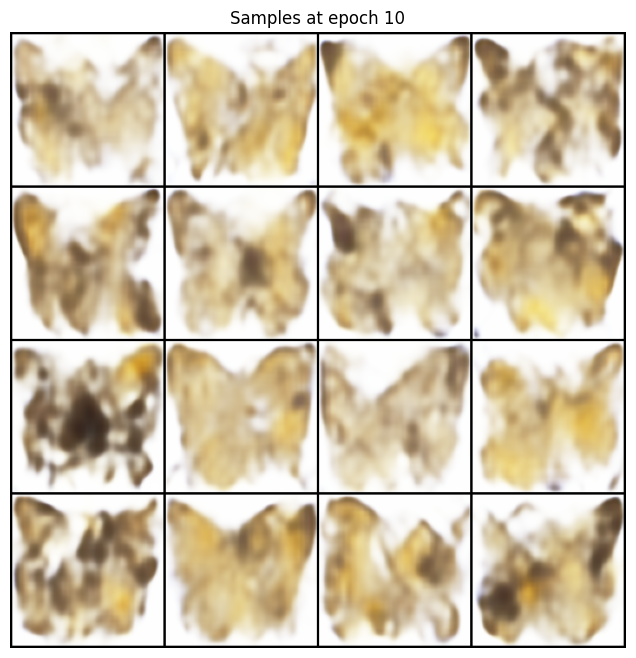

Train :: Epoch: 20: 100%|██████████| 16/16 [00:09<00:00,  1.67it/s, Epoch Loss: 0.3155]


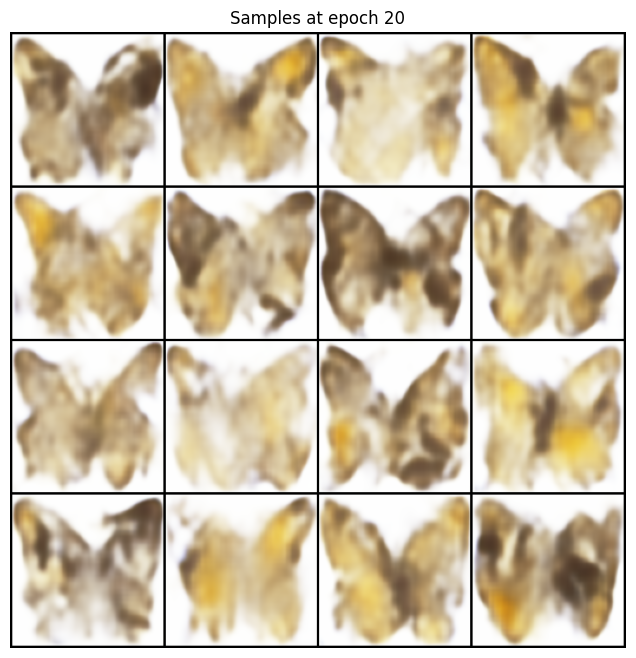

Train :: Epoch: 30: 100%|██████████| 16/16 [00:09<00:00,  1.67it/s, Epoch Loss: 0.3016]


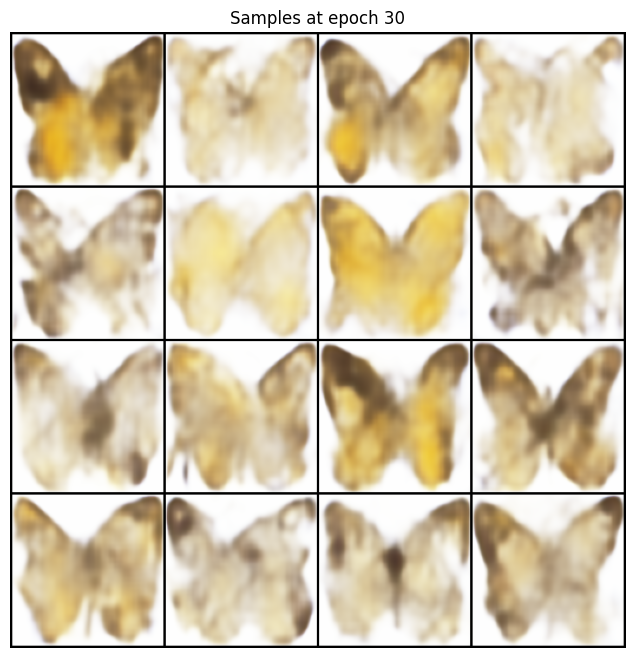

In [ ]:
# Training loop for latent diffusion
for epoch in range(1, ddpm_epochs + 1):
    torch.cuda.empty_cache()
    gc.collect()

    train_one_epoch(
        denoiser_model, diffusionmodel, train_loader, optimizer, scaler, loss_fn, vae, device, epoch=epoch
    )
    if epoch % 10 == 0:
        denoiser_model.eval()
        with torch.no_grad():
            z_T = torch.randn(16, *latent_shape, device=device)
            z = z_T
            for t in reversed(range(diffusionmodel.timesteps)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = denoiser_model(z, t_batch)
                z = diffusionmodel.step_backward(eps_pred, z, t)
            x_gen = vae.decode(z)
            x_gen = x_gen.cpu().clamp(0, 1)
            grid = torchvision.utils.make_grid(x_gen, nrow=4)
            plt.figure(figsize=(8,8)); plt.axis('off'); plt.title(f"Samples at epoch {epoch}")
            plt.imshow(grid.permute(1,2,0).squeeze()); plt.show()

In [ ]:
# Save trained DDPM score network
torch.save(denoiser_model.state_dict(), "latent_ddpm_score_net_butterflies.pth")
print("Latent DDPM score model trained and saved.")

Latent DDPM score model trained and saved.


Sampling :: 100%|██████████| 10/10 [00:00<00:00, 25.08it/s]


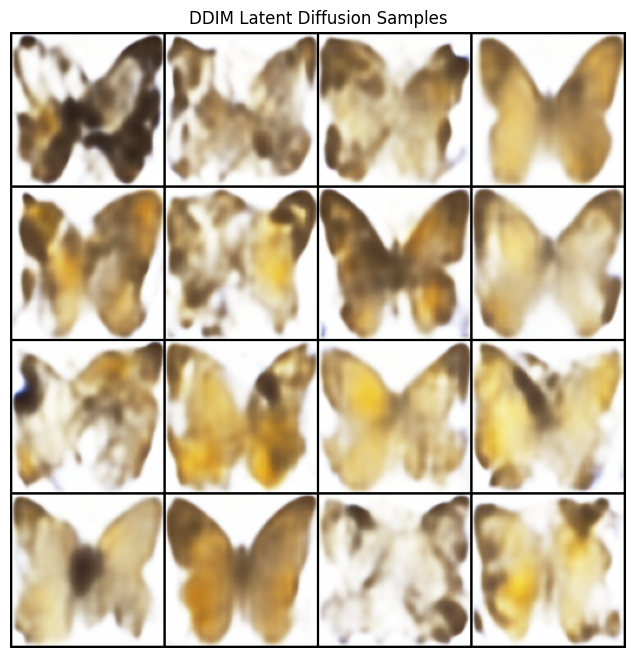

In [ ]:
# DDIM sampling for latent diffusion (no class conditioning)
@torch.inference_mode()
def generate_ddim(denoiser_model, taus, backward_sampler, size, device):
    xnoisy = torch.randn(size, device=device)
    # Set the model in evaluation mode
    denoiser_model.eval()
    last_t = torch.ones(size[0], dtype=torch.long, device=device) * (backward_sampler.timesteps-1)
    alpha_bar_t = get_from_idx(backward_sampler.alpha_bar, last_t)
    sqrt_alpha_bar_t = get_from_idx(backward_sampler.sqrt_alpha_bar, last_t)
    sqrt_one_minus_alpha_bar_t = get_from_idx(backward_sampler.sqrt_one_minus_alpha_bar, last_t)
    # Now, to reverse the diffusion process, use a sequence of denoising steps
    for t in tqdm(iterable=reversed(taus),
                  dynamic_ncols=False,total=len(taus),
                  desc="Sampling :: ", position=0):
        # Time vectors
        ts = torch.ones(size[0], dtype=torch.long, device=device) * t
        predicted_noise = denoiser_model(xnoisy, ts)
        alpha_bar_t_prev = get_from_idx(backward_sampler.alpha_bar, ts)
        sqrt_alpha_bar_t_prev = get_from_idx(backward_sampler.sqrt_alpha_bar, ts)
        sqrt_one_minus_alpha_bar_t_prev = get_from_idx(backward_sampler.sqrt_one_minus_alpha_bar, ts)
        predicted_x0 = (xnoisy - sqrt_one_minus_alpha_bar_t * predicted_noise) / sqrt_alpha_bar_t
        xnoisy = sqrt_alpha_bar_t_prev * predicted_x0 + sqrt_one_minus_alpha_bar_t_prev * predicted_noise
        alpha_bar_t = alpha_bar_t_prev
        sqrt_alpha_bar_t = sqrt_alpha_bar_t_prev
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar_t_prev
    return xnoisy

# Example usage for latent diffusion:
taus = np.arange(0, diffusionmodel.timesteps, 100)
z_latents = generate_ddim(denoiser_model, taus, diffusionmodel, (16, *latent_shape), device)
x_gen = vae.decode(z_latents)
x_gen = x_gen.cpu().clamp(0, 1)
grid = torchvision.utils.make_grid(x_gen, nrow=4)
plt.figure(figsize=(8,8)); plt.axis('off'); plt.title("DDIM Latent Diffusion Samples")
plt.imshow(grid.permute(1,2,0).squeeze()); plt.show()

  0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipython-input-2619837498.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 16/16 [09:09<00:00, 34.33s/it]


Joint Epoch 1/100 | Avg VAE ELBO: 1046.7086 | Avg Diff Loss: 0.0048


100%|██████████| 16/16 [09:10<00:00, 34.38s/it]


Joint Epoch 2/100 | Avg VAE ELBO: 1024.6955 | Avg Diff Loss: 0.0050


100%|██████████| 16/16 [09:13<00:00, 34.57s/it]


...

Joint Epoch 8/100 | Avg VAE ELBO: 1001.0257 | Avg Diff Loss: 0.0048


100%|██████████| 16/16 [06:00<00:00, 22.52s/it]


Joint Epoch 9/100 | Avg VAE ELBO: 1003.3949 | Avg Diff Loss: 0.0050


100%|██████████| 16/16 [05:49<00:00, 21.87s/it]


Joint Epoch 10/100 | Avg VAE ELBO: 993.5244 | Avg Diff Loss: 0.0046


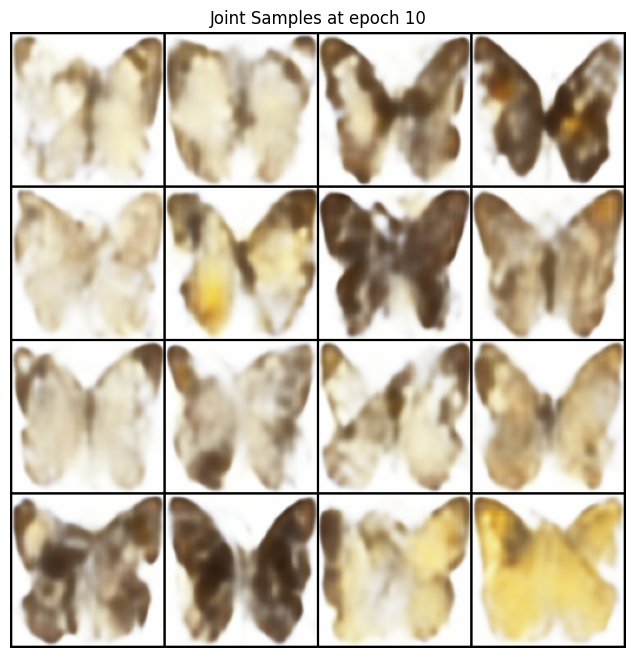

100%|██████████| 16/16 [05:51<00:00, 21.98s/it]


Joint Epoch 11/100 | Avg VAE ELBO: 991.3254 | Avg Diff Loss: 0.0048


100%|██████████| 16/16 [05:55<00:00, 22.19s/it]


Joint Epoch 12/100 | Avg VAE ELBO: 987.2108 | Avg Diff Loss: 0.0050


100%|██████████| 16/16 [05:52<00:00, 22.02s/it]


...

Joint Epoch 18/100 | Avg VAE ELBO: 974.5467 | Avg Diff Loss: 0.0044


100%|██████████| 16/16 [05:50<00:00, 21.88s/it]


Joint Epoch 19/100 | Avg VAE ELBO: 973.5460 | Avg Diff Loss: 0.0046


100%|██████████| 16/16 [05:51<00:00, 21.98s/it]


Joint Epoch 20/100 | Avg VAE ELBO: 966.2031 | Avg Diff Loss: 0.0046


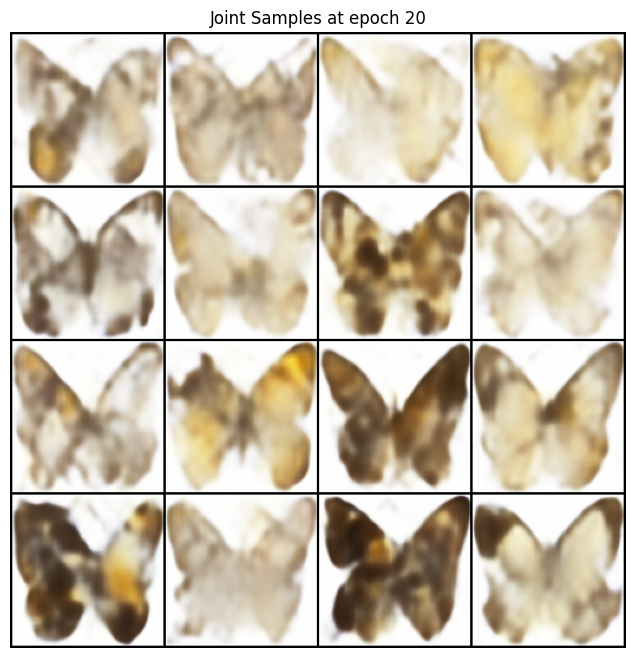

100%|██████████| 16/16 [06:55<00:00, 25.99s/it]


Joint Epoch 21/100 | Avg VAE ELBO: 969.6208 | Avg Diff Loss: 0.0045


100%|██████████| 16/16 [06:57<00:00, 26.06s/it]


Joint Epoch 22/100 | Avg VAE ELBO: 975.8652 | Avg Diff Loss: 0.0046


100%|██████████| 16/16 [07:52<00:00, 29.54s/it]


...

100%|██████████| 16/16 [06:21<00:00, 23.82s/it]


Joint Epoch 26/100 | Avg VAE ELBO: 962.8235 | Avg Diff Loss: 0.0046


100%|██████████| 16/16 [06:00<00:00, 22.52s/it]


Joint Epoch 27/100 | Avg VAE ELBO: 956.1178 | Avg Diff Loss: 0.0047


 69%|██████▉   | 11/16 [04:32<02:27, 29.42s/it]

In [ ]:
# Unfreeze VAE parameters for joint training
for param in vae.parameters():
    param.requires_grad_(True)

# New optimizer for both VAE and diffusion model
joint_optimizer = torch.optim.AdamW(
    list(vae.parameters()) + list(denoiser_model.parameters()), lr=1e-4
)

joint_epochs = 100  # Number of joint training epochs (adjust as needed)

for epoch in range(1, joint_epochs + 1):
    vae.train()
    denoiser_model.train()
    total_vae_loss = 0.0
    total_diff_loss = 0.0
    for x in tqdm(train_loader):
        x = x.to(device)
        x_recon, mu, log_var = vae(x)
        vae_elbo = vae_loss(x, x_recon, mu, log_var)

        # Get latent z spatially
        z = reparameterize(mu, log_var)

        # Diffusion loss
        t = torch.randint(0, diffusionmodel.timesteps, (z.size(0),), device=device)
        z_t, eps_true = diffusionmodel(z, t)
        with torch.cuda.amp.autocast():
            eps_pred = denoiser_model(z_t, t)
            diff_loss = loss_fn(eps_pred, eps_true)

        # Joint loss
        loss = vae_elbo + diff_loss

        joint_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        joint_optimizer.step()

        total_vae_loss += vae_elbo.item()
        total_diff_loss += diff_loss.item()
    avg_vae_loss = total_vae_loss / len(train_loader.dataset)
    avg_diff_loss = total_diff_loss / len(train_loader.dataset)
    print(f"Joint Epoch {epoch}/{joint_epochs} | Avg VAE ELBO: {avg_vae_loss:.4f} | Avg Diff Loss: {avg_diff_loss:.4f}")
    if epoch % 10 == 0:
        denoiser_model.eval()
        vae.eval()
        with torch.no_grad():
            z_T = torch.randn(16, *latent_shape, device=device)
            z = z_T
            for t in reversed(range(diffusionmodel.timesteps)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = denoiser_model(z, t_batch)
                z = diffusionmodel.step_backward(eps_pred, z, t)
            x_gen = vae.decode(z)
            x_gen = x_gen.cpu().clamp(0, 1)
            grid = torchvision.utils.make_grid(x_gen, nrow=4)
            plt.figure(figsize=(8,8)); plt.axis('off'); plt.title(f"Joint Samples at epoch {epoch}")
            plt.imshow(grid.permute(1,2,0).squeeze()); plt.show()